Setup & Load

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(root) not in sys.path:
    sys.path.append(str(root))

HOUSE = os.environ.get("SMART_HOME_HOUSE", "hh101")
processed_path = root / "data" / "processed" / f"{HOUSE}_features_with_models.csv"
if not processed_path.exists():
    raise FileNotFoundError(f"Modeled features not found: {processed_path}")

fig_dir = root / "outputs" / "figures" / HOUSE
table_dir = root / "outputs" / "tables" / HOUSE
fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(processed_path)
df["window_start"] = pd.to_datetime(df["window_start"])
df["hour"] = df["window_start"].dt.hour + df["window_start"].dt.minute/60
df["dow"] = df["window_start"].dt.dayofweek
print(f"Loaded {len(df)} modeled windows for {HOUSE} from {processed_path}")
df.head()

Loaded 107127 modeled windows for hh101 from C:\Users\evang\Documents\GitHub\smart-home-anomaly-detection\data\processed\hh101_features_with_models.csv


,window_start,Bathroom,Bedroom,DiningRoom,Kitchen,LivingRoom,OutsideDoor,total_events,n_sensors_active,tod_sin,tod_cos,dow,is_inactive,cluster,is_anomaly,anomaly_score,hour
0,2012-07-18 12:50:00,2.0,5.0,1.0,5.0,4.0,2.0,19.0,6.0,-0.216440,-0.976296,2,0,5,False,0.043548,12.833333
1,2012-07-18 12:55:00,0.0,2.0,1.0,4.0,3.0,1.0,11.0,5.0,-0.237686,-0.971342,2,0,5,False,0.089733,12.916667
2,2012-07-18 13:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.258819,-0.965926,2,1,0,False,0.200483,13.000000
3,2012-07-18 13:05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.279829,-0.960050,2,1,0,False,0.200483,13.083333
4,2012-07-18 13:10:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.300706,-0.953717,2,1,0,False,0.201155,13.166667


What sensors exist as features?

In [2]:
ignore_cols = {"window_start","cluster","is_anomaly","anomaly_score","hour","dow"}
non_sensor_cols = {"total_events","n_sensors_active","tod_sin","tod_cos","is_inactive"}
sensor_cols = [c for c in df.columns if c not in ignore_cols and c not in non_sensor_cols]
len(sensor_cols), sensor_cols[:10]

(6,
 ['Bathroom', 'Bedroom', 'DiningRoom', 'Kitchen', 'LivingRoom', 'OutsideDoor'])

Cluster size and time-of-day profile

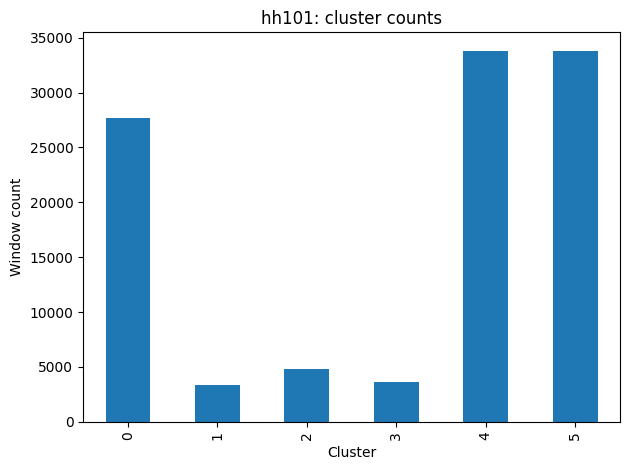

cluster
0    27669
1     3378
2     4835
3     3664
4    33785
5    33796
Name: count, dtype: int64

In [3]:
cluster_counts = df["cluster"].value_counts().sort_index()
cluster_counts.to_csv(table_dir / f"{HOUSE}_cluster_counts.csv", header=["window_count"])

plt.figure()
cluster_counts.plot(kind="bar")
plt.title(f"{HOUSE}: cluster counts")
plt.xlabel("Cluster")
plt.ylabel("Window count")
plt.tight_layout()
plt.savefig(fig_dir / f"{HOUSE}_cluster_counts.png", bbox_inches="tight")
plt.show()

cluster_counts

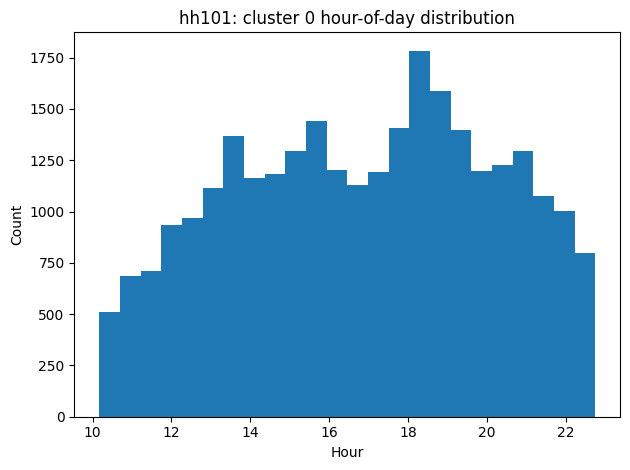

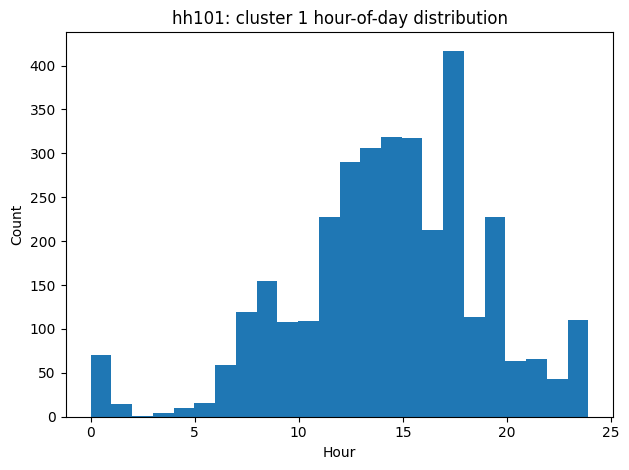

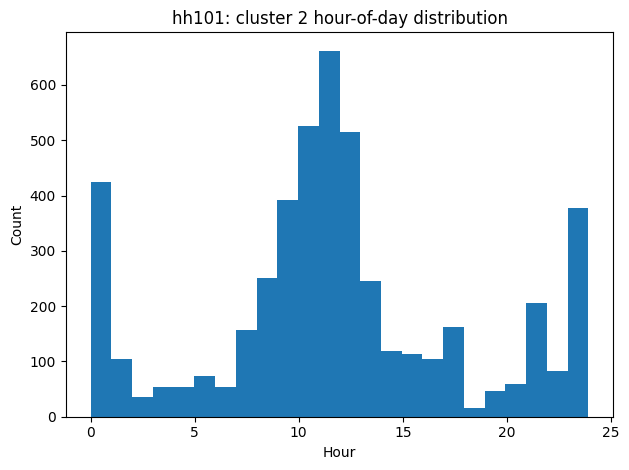

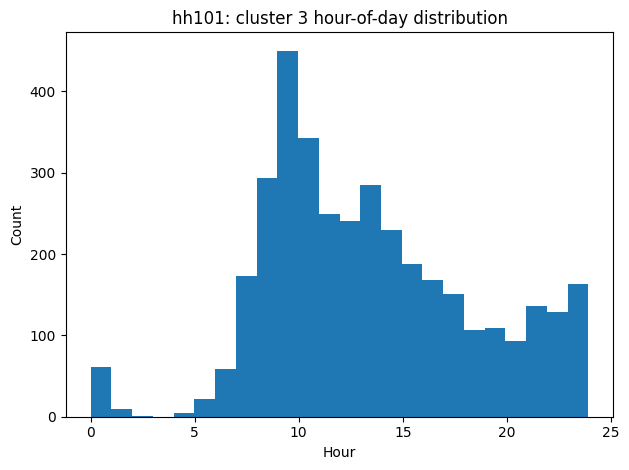

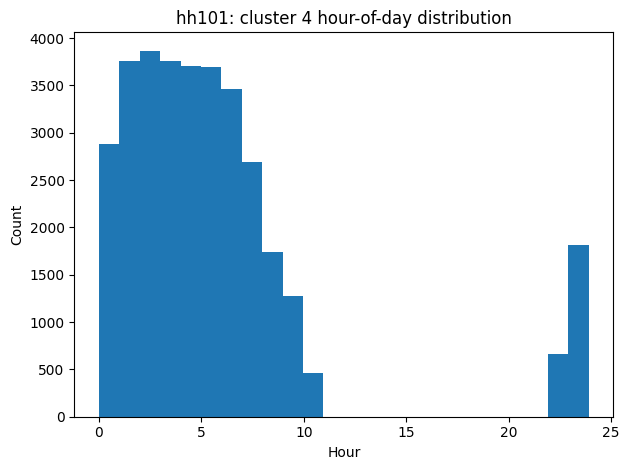

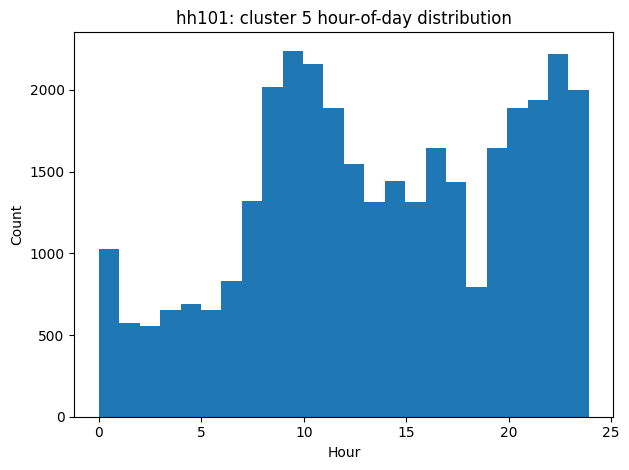

In [4]:
# Time-of-day distribution per cluster
for k in sorted(df["cluster"].unique()):
    hours = df.loc[df["cluster"]==k, "hour"].values
    plt.figure()
    plt.hist(hours, bins=24)
    plt.title(f"{HOUSE}: cluster {k} hour-of-day distribution")
    plt.xlabel("Hour")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(fig_dir / f"{HOUSE}_cluster_{k}_hour_distribution.png", bbox_inches="tight")
    plt.show()

Top sensors per cluster

In [5]:
def top_sensors_for_cluster(k, topn=10):
    sub = df[df["cluster"]==k]
    active_sub = sub[sub["total_events"] > 0] if "total_events" in sub.columns else sub
    ref = active_sub if not active_sub.empty else sub
    means = ref[sensor_cols].mean().sort_values(ascending=False)
    if active_sub.empty or means.empty or float(means.max()) <= 0:
        return pd.Series([0.0], index=["No active sensor"])
    return means.head(topn)

for k in sorted(df["cluster"].unique()):
    print(f"\n=== Cluster {k} top sensors ===")
    print(top_sensors_for_cluster(k, topn=12))


=== Cluster 0 top sensors ===
No active sensor    0.0
dtype: float64

=== Cluster 1 top sensors ===
LivingRoom     23.826229
OutsideDoor     9.960332
Bathroom        8.222617
Bedroom         7.468917
Kitchen         7.239195
DiningRoom      1.117525
dtype: float64

=== Cluster 2 top sensors ===
Bedroom        45.175181
Bathroom       34.072182
LivingRoom      4.393588
Kitchen         1.229783
OutsideDoor     0.599793
DiningRoom      0.180145
dtype: float64

=== Cluster 3 top sensors ===
Kitchen        63.809771
LivingRoom     14.412664
DiningRoom      5.009825
Bathroom        3.577238
Bedroom         2.569869
OutsideDoor     0.690775
dtype: float64

=== Cluster 4 top sensors ===
No active sensor    0.0
dtype: float64

=== Cluster 5 top sensors ===
LivingRoom     7.952923
Bedroom        1.156172
Kitchen        0.541958
Bathroom       0.470233
OutsideDoor    0.069357
DiningRoom     0.069121
dtype: float64


Cluster summary table you can paste into report

In [6]:
summary_rows = []
for k in sorted(df["cluster"].unique()):
    sub = df[df["cluster"]==k]
    top_sensors = top_sensors_for_cluster(k, topn=2)
    row = {
        "cluster": k,
        "n_windows": len(sub),
        "mean_total_events": sub["total_events"].mean(),
        "mean_unique_sensors": sub["n_sensors_active"].mean(),
        "inactive_fraction": (sub["total_events"] == 0).mean(),
        "peak_hour": sub["hour"].round().mode().iloc[0] if len(sub) else np.nan,
        "top_sensor_1": top_sensors.index[0] if len(top_sensors) > 0 else "",
        "top_sensor_2": top_sensors.index[1] if len(top_sensors) > 1 and top_sensors.index[0] != "No active sensor" else "",
    }
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows).sort_values("cluster")
summary.to_csv(table_dir / f"{HOUSE}_cluster_summary.csv", index=False)
summary

,cluster,n_windows,mean_total_events,mean_unique_sensors,inactive_fraction,peak_hour,top_sensor_1,top_sensor_2
0,0,27669,0.000000,0.000000,1.0,18.0,No active sensor,
1,1,3378,57.834813,3.346359,0.0,14.0,LivingRoom,OutsideDoor
2,2,4835,85.650672,2.232678,0.0,12.0,Bedroom,Bathroom
3,3,3664,90.070142,3.088701,0.0,10.0,Kitchen,LivingRoom
4,4,33785,0.000000,0.000000,1.0,2.0,No active sensor,
5,5,33796,10.259764,1.122293,0.0,10.0,LivingRoom,Bedroom


Assign human-readable routine labels

In [7]:
# Fill this after inspecting time histograms + top sensors
cluster_name = {
    0: "Night inactivity",
    1: "Morning kitchen routine",
    2: "Evening routine",
    # ...
}

df["routine_label"] = df["cluster"].map(cluster_name).fillna("Unlabeled routine")
df[["window_start","cluster","routine_label","total_events","n_sensors_active"]].head(20)

,window_start,cluster,routine_label,total_events,n_sensors_active
0,2012-07-18 12:50:00,5,Unlabeled routine,19.0,6.0
1,2012-07-18 12:55:00,5,Unlabeled routine,11.0,5.0
2,2012-07-18 13:00:00,0,Night inactivity,0.0,0.0
3,2012-07-18 13:05:00,0,Night inactivity,0.0,0.0
4,2012-07-18 13:10:00,0,Night inactivity,0.0,0.0
5,2012-07-18 13:15:00,0,Night inactivity,0.0,0.0
6,2012-07-18 13:20:00,0,Night inactivity,0.0,0.0
7,2012-07-18 13:25:00,0,Night inactivity,0.0,0.0
8,2012-07-18 13:30:00,0,Night inactivity,0.0,0.0
9,2012-07-18 13:35:00,0,Night inactivity,0.0,0.0
